In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from Greedy_SOSP import Greedy_SOSP

DATA_PATH = Path("data") / "bangalore_road_drive.txt"
RESULTS_GSOSP_CSV = Path("bangalore_road_drive_results_GSOSP.csv")

In [2]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 393,513 edges from data\bangalore_road_drive.txt


In [3]:
EDGE_COUNTS = [40_000, 80_000, 120_000, 160_000, 200_000, 240_000, 280_000, 320_000, 360_000, len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Greedy_SOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 50/50 [00:41<00:00,  1.21it/s]


,edges,nodes,runtime,trial
0,40000,26545,0.035337,1
1,40000,26545,0.034239,2
2,40000,26545,0.035404,3
3,40000,26545,0.045620,4
4,40000,26545,0.043681,5


In [4]:
results_df.to_csv(RESULTS_GSOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_GSOSP_CSV}")

Saved runtime results to bangalore_road_drive_results_GSOSP.csv


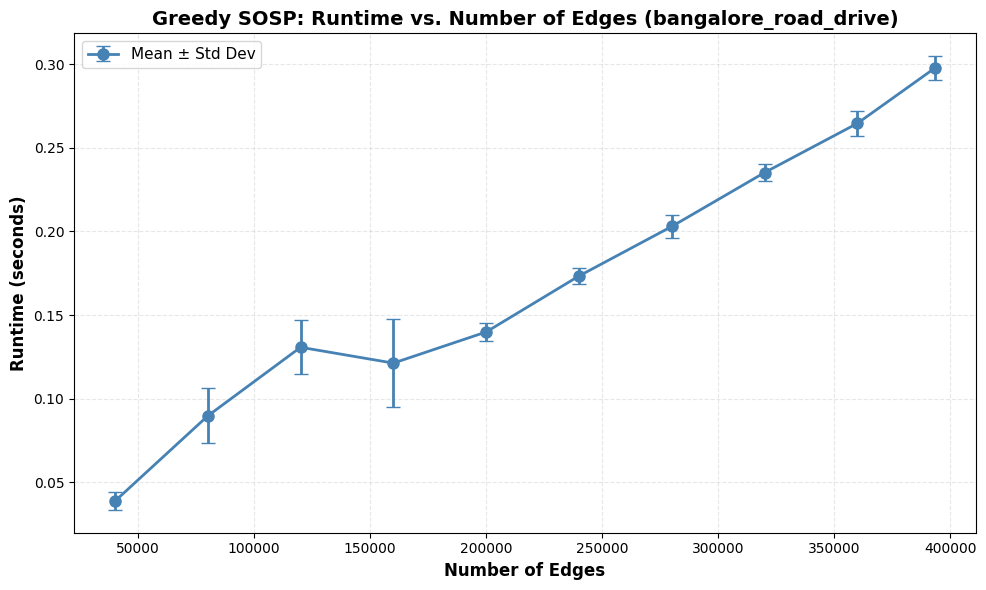


Runtime Statistics by Edges:
 edges     mean      std
 40000 0.038856 0.005353
 80000 0.089781 0.016469
120000 0.130779 0.016151
160000 0.121314 0.026349
200000 0.139925 0.005459
240000 0.173371 0.004891
280000 0.202968 0.006820
320000 0.235178 0.004980
360000 0.264576 0.007425
393513 0.297736 0.007108


In [5]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Greedy SOSP: Runtime vs. Number of Edges (bangalore_road_drive)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

In [6]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from Robust_MOSP import  Robust_MOSP

DATA_PATH = Path("data") / "bangalore_road_drive.txt"
RESULTS_RMOSP_CSV = Path("bangalore_road_drive_results_RMOSP.csv")

In [7]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 393,513 edges from data\bangalore_road_drive.txt


In [8]:
EDGE_COUNTS = [40_000, 80_000, 120_000, 160_000, 200_000, 240_000, 280_000, 320_000, 360_000, len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Robust_MOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 50/50 [18:40<00:00, 22.41s/it]


,edges,nodes,runtime,trial
0,40000,26545,5.177582,1
1,40000,26545,4.391159,2
2,40000,26545,4.336317,3
3,40000,26545,4.453510,4
4,40000,26545,3.668519,5


In [9]:
results_df.to_csv(RESULTS_RMOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_RMOSP_CSV}")

Saved runtime results to bangalore_road_drive_results_RMOSP.csv


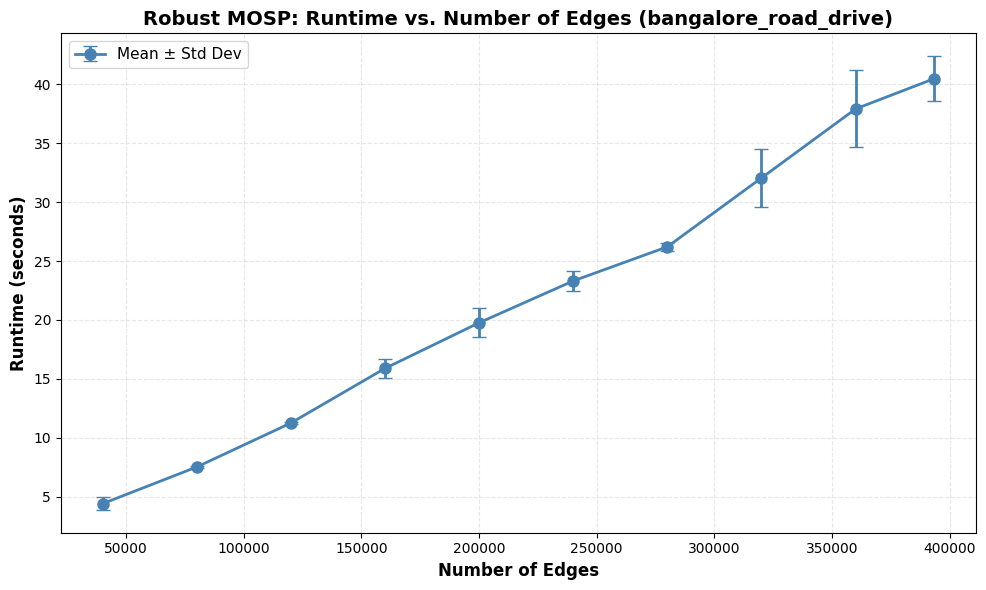


Runtime Statistics by Edges:
 edges      mean      std
 40000  4.405417 0.535385
 80000  7.519073 0.051616
120000 11.251620 0.093847
160000 15.888817 0.779366
200000 19.763044 1.223768
240000 23.313935 0.837714
280000 26.212880 0.353831
320000 32.055561 2.492332
360000 37.916951 3.264855
393513 40.495059 1.911398


In [10]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Robust MOSP: Runtime vs. Number of Edges (bangalore_road_drive)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))